In [8]:
import torch
import os
import numpy as np
import json
import pandas as pd
from typing import List, Dict, Optional, Tuple
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
!pip install faiss-cpu
import faiss
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
!pip install jsonlines
import jsonlines
from pathlib import Path
# Set seeds
np.random.seed(42)
torch.manual_seed(42)

print("✓ All imports successful")

✓ All imports successful


In [9]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/My Drive/NLP research'

print("Loading all data...")

#MedQA Loader

class MedQALoader:
    """Load USMLE-style MedQA questions"""

    def __init__(self, base_path):
        self.base_path = base_path
        self.data_dir = f'{base_path}/data_clean/questions/US'

    def load_split(self, split='train'):
        """Load train/test/dev split"""
        file_path = f'{self.data_dir}/{split}.jsonl'

        data = []
        try:
            with jsonlines.open(file_path) as f:
                for obj in f:
                    raw_answer_idx = obj.get('answer_idx', 0)
                    options_raw = obj.get('options', [])


                    if isinstance(raw_answer_idx, str):
                        letter = raw_answer_idx.strip()
                        letter_to_idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3,
                                        'a': 0, 'b': 1, 'c': 2, 'd': 3}
                        answer_idx = letter_to_idx.get(letter, 0)
                    else:
                        answer_idx = int(raw_answer_idx)


                    options = []
                    if isinstance(options_raw, dict):


                        ordered_keys = ['A', 'B', 'C', 'D', 'E']
                        for key in ordered_keys:
                            if key in options_raw:
                                options.append(options_raw[key])
                    elif isinstance(options_raw, list):
                        options = options_raw
                    else:
                        print(f"      Warning: Unexpected options format: {type(options_raw)}. Defaulting to empty list.")
                        options = []


                    if not (0 <= answer_idx < len(options)):
                        answer_idx = 0

                    data.append({
                        'question': obj.get('question', ''),
                        'options': options,
                        'answer_idx': answer_idx,
                        'answer': options[answer_idx] if options else '',
                        'source': 'MedQA'
                    })
        except FileNotFoundError:
            print(f"    File not found: {file_path}")
        except Exception as e:
            print(f"    Error processing entry in {file_path}: {e}")

        return data


    def load_all(self):
        return {
            'train': self.load_split('train'),
            'test': self.load_split('test'),
            'dev': self.load_split('dev')
        }


# MedMCQA Loader

class MedMCQALoader:
    """Load Indian medical exam questions"""

    def __init__(self, base_path):
        self.base_path = base_path
        self.data_dir = f'{base_path}/MEDMCQQA'

    def load_split(self, split='train'):
        """Load train/test/dev split (handles JSONL format)"""
        file_path = f'{self.data_dir}/{split}.json'

        data = []
        try:

            print(f"    Trying JSONL format: {file_path}")
            with jsonlines.open(file_path) as f:
                for item in f:
                    options = [item.get('opa', ''), item.get('opb', ''),
                               item.get('opc', ''), item.get('opd', '')]
                    correct_idx = item.get('cop', 0)

                    data.append({
                        'question': item.get('question', ''),
                        'options': options,
                        'answer_idx': correct_idx,
                        'answer': options[correct_idx] if correct_idx < len(options) else '',
                        'source': 'MedMCQA'
                    })
            print(f"    ✓ Loaded {len(data)} items from JSONL")

        except Exception as e1:
            print(f"    JSONL failed: {str(e1)[:50]}, trying standard JSON...")

            try:
                with open(file_path, 'r') as f:
                    items = json.load(f)

                if not isinstance(items, list):
                    items = [items]

                for item in items:
                    options = [item.get('opa', ''), item.get('opb', ''),
                               item.get('opc', ''), item.get('opd', '')]
                    correct_idx = item.get('cop', 0)

                    data.append({
                        'question': item.get('question', ''),
                        'options': options,
                        'answer_idx': correct_idx,
                        'answer': options[correct_idx] if correct_idx < len(options) else '',
                        'source': 'MedMCQA'
                    })
                print(f"    ✓ Loaded {len(data)} items from JSON")

            except FileNotFoundError:
                print(f"    File not found: {file_path}")
            except Exception as e2:
                print(f"    Error loading {split}: {str(e2)[:100]}")

        return data

    def load_all(self):
        return {
            'train': self.load_split('train'),
            'test': self.load_split('test'),
            'dev': self.load_split('dev')
        }

#MMLU-Med Loader

class MLLUMedLoader:
    """Load MMLU medical subset"""

    def __init__(self, base_path):
        self.base_path = base_path
        self.data_dir = f'{base_path}/MMLU-Med'
        self.medical_subjects = [
            'clinical_knowledge', 'college_medicine', 'medical_genetics',
            'professional_medicine', 'anatomy', 'nutrition'
        ]

    def load_split(self, split='test'):
        """Load test/val/dev split"""
        data = []

        for subject in self.medical_subjects:
            file_path = f'{self.data_dir}/{split}/{subject}_{split}.csv'

            try:

                df = pd.read_csv(file_path, header=None)

                for idx, row in df.iterrows():
                    try:
                        question = str(row.iloc[0])
                        option_a = str(row.iloc[1])
                        option_b = str(row.iloc[2])
                        option_c = str(row.iloc[3])
                        option_d = str(row.iloc[4])
                        answer_letter = str(row.iloc[5])

                        options = [option_a, option_b, option_c, option_d]
                        answer_idx = {
                            'A': 0, 'B': 1, 'C': 2, 'D': 3,
                            'a': 0, 'b': 1, 'c': 2, 'd': 3
                        }.get(answer_letter, 0)

                        data.append({
                            'question': question,
                            'options': options,
                            'answer_idx': answer_idx,
                            'answer': options[answer_idx] if answer_idx < len(options) else '',
                            'subject': subject,
                            'source': 'MMLU-Med'
                        })
                    except Exception as e:
                        print(f"      Warning: Error parsing row {idx}: {str(e)[:50]}")
                        continue

            except FileNotFoundError:
                print(f"        File not found: {file_path}")
            except Exception as e:
                print(f"        Error loading {subject}/{split}: {str(e)[:100]}")

        return data

    def load_all(self):
        return {
            'test': self.load_split('test'),
            'val': self.load_split('val'),
            'dev': self.load_split('dev')
        }


#PubMed Corpus Loader

class PubMedCorpusLoader:
    """Load PubMed abstracts"""

    def __init__(self, base_path):
        self.base_path = base_path
        self.file_path = f'{base_path}/pubmed_abstracts.json'

    def load(self):
        """Load PubMed corpus"""
        documents = []

        try:
            with open(self.file_path, 'r') as f:
                data = json.load(f)

            abstracts = data if isinstance(data, list) else (
                data.get('abstracts', data.values()) if isinstance(data, dict) else []
            )

            for i, abstract in enumerate(abstracts):
                doc = {
                    'id': f'pubmed_{i}',
                    'content': str(abstract)[:512] if abstract else '',
                    'source': 'pubmed',
                }
                documents.append(doc)

        except FileNotFoundError:
            print(f"    File not found: {self.file_path}")

        return documents


# Textbook Corpus Loader

class TextbookCorpusLoader:
    """Load medical textbooks"""

    def __init__(self, base_path, language='en'):
        self.base_path = base_path
        self.language = language
        self.data_dir = f'{base_path}/data_clean/textbooks/{language}'

    def load(self):
        """Load textbook corpus"""
        documents = []
        doc_id = 0

        try:
            textbook_files = list(Path(self.data_dir).glob('*.txt'))

            for textbook_path in textbook_files:
                try:
                    with open(textbook_path, 'r', encoding='utf-8') as f:
                        content = f.read()

                    chunks = content.split('\n\n')

                    for chunk in chunks:
                        if len(chunk.strip()) > 50:
                            doc = {
                                'id': f'textbook_{doc_id}',
                                'content': chunk.strip()[:512],
                                'source': 'textbook',
                                'textbook': textbook_path.stem,
                            }
                            documents.append(doc)
                            doc_id += 1

                except Exception as e:
                    print(f"    Error reading {textbook_path}: {e}")

        except FileNotFoundError:
            print(f"    Directory not found: {self.data_dir}")

        return documents


# UNIFIED MANAGER CLASS

class RAG2DataManager:
    """Unified manager for all datasets and corpus from Google Drive"""

    def __init__(self, base_path, verbose=True):
        self.base_path = base_path
        self.verbose = verbose

        self.medqa_loader = MedQALoader(base_path)
        self.medmcqa_loader = MedMCQALoader(base_path)
        self.mmlu_loader = MLLUMedLoader(base_path)
        self.pubmed_loader = PubMedCorpusLoader(base_path)
        self.textbook_loader = TextbookCorpusLoader(base_path, language='en')

    def load_qa_datasets(self):
        """Load all QA datasets"""
        if self.verbose:
            print("\n" + "="*60)
            print("Loading QA Datasets from Google Drive")
            print("="*60)

        datasets = {}

        if self.verbose:
            print("\n[1/3] Loading MedQA (USMLE)...")
        datasets['medqa'] = self.medqa_loader.load_all()
        if self.verbose:
            print(f"  ✓ MedQA: {len(datasets['medqa']['train'])} train, {len(datasets['medqa']['test'])} test")

        if self.verbose:
            print("\n[2/3] Loading MedMCQA (Indian Medical Exams)...")
        datasets['medmcqa'] = self.medmcqa_loader.load_all()
        if self.verbose:
            print(f"  ✓ MedMCQA: {len(datasets['medmcqa']['train'])} train, {len(datasets['medmcqa']['test'])} test")

        if self.verbose:
            print("\n[3/3] Loading MMLU-Med...")
        datasets['mmlu'] = self.mmlu_loader.load_all()
        if self.verbose:
            print(f"  ✓ MMLU-Med: {len(datasets['mmlu']['test'])} test")

        if self.verbose:
            print("\n" + "="*60)

        return datasets

    def load_corpus(self, include_pubmed=True, include_textbooks=True):
        """Load retrieval corpus"""
        if self.verbose:
            print("\n" + "="*60)
            print("Loading Retrieval Corpus from Google Drive")
            print("="*60)

        corpus = {
            'pubmed': [],
            'textbooks': [],
        }

        if include_pubmed:
            if self.verbose:
                print("\n[1/2] Loading PubMed Abstracts...")
            corpus['pubmed'] = self.pubmed_loader.load()
            if self.verbose:
                print(f"  ✓ PubMed: {len(corpus['pubmed'])} documents")

        if include_textbooks:
            if self.verbose:
                print("\n[2/2] Loading Medical Textbooks...")
            corpus['textbooks'] = self.textbook_loader.load()
            if self.verbose:
                print(f"  ✓ Textbooks: {len(corpus['textbooks'])} documents")

        all_corpus = corpus['pubmed'] + corpus['textbooks']

        if self.verbose:
            print("\n" + "="*60)
            print(f"Total corpus size: {len(all_corpus)} documents")
            print("="*60)

        return all_corpus, corpus

    def load_all(self):
        """Load everything"""
        qa_datasets = self.load_qa_datasets()
        corpus, corpus_split = self.load_corpus()

        return {
            'qa_datasets': qa_datasets,
            'corpus': corpus,
            'corpus_split': corpus_split
        }


data_manager = RAG2DataManager(BASE_PATH, verbose=True)
all_data = data_manager.load_all()

medqa_train = all_data['qa_datasets']['medqa']['train']
medqa_test = all_data['qa_datasets']['medqa']['test']
medmcqa_train = all_data['qa_datasets']['medmcqa']['train']
medmcqa_test = all_data['qa_datasets']['medmcqa']['test']
mmlu_test = all_data['qa_datasets']['mmlu']['test']

corpus = all_data['corpus']
corpus_split = all_data['corpus_split']

print("\n✓ ALL DATA LOADED SUCCESSFULLY")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading all data...

Loading QA Datasets from Google Drive

[1/3] Loading MedQA (USMLE)...
  ✓ MedQA: 10178 train, 1273 test

[2/3] Loading MedMCQA (Indian Medical Exams)...
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/train.json
    ✓ Loaded 182822 items from JSONL
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/test.json
    ✓ Loaded 6150 items from JSONL
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/dev.json
    ✓ Loaded 4183 items from JSONL
  ✓ MedMCQA: 182822 train, 6150 test

[3/3] Loading MMLU-Med...
  ✓ MMLU-Med: 1251 test


Loading Retrieval Corpus from Google Drive

[1/2] Loading PubMed Abstracts...
  ✓ PubMed: 5853 documents

[2/2] Loading Medical Textbooks...
  ✓ Textbooks: 177465 documents

Total corpus size: 183318 documents

✓ ALL DATA LOADED SUCCESSFULLY


In [10]:
# Load generator
print("[1/4] Loading Qwen/Qwen2.5-7B (Answer Generation)...")
generator_model_name = "Qwen/Qwen2.5-7B"
generator_tokenizer = AutoTokenizer.from_pretrained(
    generator_model_name,
    trust_remote_code=True
)
generator_model = AutoModelForCausalLM.from_pretrained(
    generator_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
generator_model.eval()
print(f"✓ Generator loaded: {generator_model_name}")

# Load filter model
print("[2/4] Loading Flan-T5-Large (Relevance Filter)...")
filter_model_name = "google/flan-t5-large"
filter_tokenizer = AutoTokenizer.from_pretrained(filter_model_name)
filter_model = AutoModelForSeq2SeqLM.from_pretrained(
    filter_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
filter_model.eval()
print(f"✓ Filter loaded: {filter_model_name}")

# Load embedder
print("[3/4] Loading MedCPT Query Encoder (Dense Retrieval)...")
embedder_name = "ncbi/MedCPT-Query-Encoder"
embedder = SentenceTransformer(embedder_name, device="cuda")
print(f"✓ Embedder loaded: {embedder_name}")

# Load dataset from Google Drive
print("[4/4] Loading MedQA Dataset from Google Drive...")
data_manager = RAG2DataManager(BASE_PATH, verbose=True)
all_data = data_manager.load_all()
medqa_train = all_data['qa_datasets']['medqa']['train']
medqa_test = all_data['qa_datasets']['medqa']['test']
corpus_split = all_data['corpus_split']
print(f"✓ MedQA loaded: {len(medqa_train)} train, {len(medqa_test)} test")

print("\n" + "="*80)
print("✓ ALL MODELS & DATA LOADED SUCCESSFULLY")
print("="*80)


[1/4] Loading Qwen/Qwen2.5-7B (Answer Generation)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Generator loaded: Qwen/Qwen2.5-7B
[2/4] Loading Flan-T5-Large (Relevance Filter)...


✓ Filter loaded: google/flan-t5-large
[3/4] Loading MedCPT Query Encoder (Dense Retrieval)...
✓ Embedder loaded: ncbi/MedCPT-Query-Encoder
[4/4] Loading MedQA Dataset from Google Drive...

Loading QA Datasets from Google Drive

[1/3] Loading MedQA (USMLE)...
  ✓ MedQA: 10178 train, 1273 test

[2/3] Loading MedMCQA (Indian Medical Exams)...
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/train.json
    ✓ Loaded 182822 items from JSONL
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/test.json
    ✓ Loaded 6150 items from JSONL
    Trying JSONL format: /content/drive/My Drive/NLP research/MEDMCQQA/dev.json
    ✓ Loaded 4183 items from JSONL
  ✓ MedMCQA: 182822 train, 6150 test

[3/3] Loading MMLU-Med...
  ✓ MMLU-Med: 1251 test


Loading Retrieval Corpus from Google Drive

[1/2] Loading PubMed Abstracts...
  ✓ PubMed: 5853 documents

[2/2] Loading Medical Textbooks...
  ✓ Textbooks: 177465 documents

Total corpus size: 183318 documents
✓ MedQA 

In [11]:
class Document:
    """Simple wrapper for document with required methods"""
    def __init__(self, content: str, title: str = "", doc_id: str = ""):
        self.content = content
        self.title = title
        self.id = doc_id

    def get_content(self):
        return self.content

    def get_title(self):
        return self.title

    def get_id(self):
        return self.id

class FAISSBalancedRetriever:
    """
    FAISS-based dense retriever with balanced retrieval from multiple corpus sources.

    Implements:
    1. Dense embedding encoding (MedCPT)
    2. FAISS indexing for efficient similarity search
    3. Balanced retrieval across 4 corpus sources (Section 3.4 of paper)
    4. Optional reranking with cross-encoder
    """

    def __init__(self, embedder: SentenceTransformer, device: str = "cuda"):
        """Initialize FAISS retriever with external embedder"""

        self.device = device
        self.encoder = embedder
        self.embedding_dim = self.encoder.get_sentence_embedding_dimension()

        # Initialize corpus storage
        self.corpus = []  # List of all Document objects
        self.corpus_metadata = []  # Metadata: source, title, id

        # FAISS indices - one per source
        self.indices = {
            'pubmed': None,
            'pmc': None,
            'textbook': None,
            'guidelines': None
        }

        # Track corpus source boundaries
        self.source_ranges = {
            'pubmed': (0, 0),
            'pmc': (0, 0),
            'textbook': (0, 0),
            'guidelines': (0, 0)
        }

        # Global FAISS index
        self.global_index = None

        print(f"✓ Retriever initialized. Embedding dimension: {self.embedding_dim}")

    def add_documents(self, documents: List, source: str) -> None:
        """Add documents to corpus and build/update FAISS index"""

        if source not in self.indices:
            raise ValueError(f"Source must be one of {list(self.indices.keys())}")

        print(f"[Adding] {len(documents)} documents from '{source}'...")

        # Extract content for embedding
        contents = [doc.get_content() if hasattr(doc, 'get_content') else doc['content']
                    for doc in documents]

        # Encode documents
        print(f"[Encoding] {len(contents)} documents...")
        embeddings = self.encoder.encode(
            contents,
            convert_to_numpy=True,
            show_progress_bar=True,
            batch_size=32
        )
        embeddings = np.array(embeddings, dtype=np.float32)

        # Store metadata about source boundaries
        start_idx = len(self.corpus)
        end_idx = start_idx + len(documents)

        # Add to global corpus
        for doc in documents:
            if hasattr(doc, 'get_content'):
                self.corpus.append(doc)
            else:
                self.corpus.append(Document(
                    content=doc['content'],
                    title=doc.get('title', ''),
                    doc_id=doc.get('id', '')
                ))

        # Create metadata entries
        for i, doc in enumerate(documents):
            title = doc.get_title() if hasattr(doc, 'get_title') else doc.get('title', '')
            doc_id = doc.get_id() if hasattr(doc, 'get_id') else doc.get('id', '')
            self.corpus_metadata.append({
                'global_idx': start_idx + i,
                'source': source,
                'title': title,
                'id': doc_id
            })

        # Build FAISS index for this source
        print(f"[Building] FAISS index for '{source}'...")
        index = faiss.IndexFlatL2(self.embedding_dim)
        index.add(embeddings)
        self.indices[source] = index

        # Update source ranges
        self.source_ranges[source] = (start_idx, end_idx)

        print(f"✓ Added {len(documents)} from '{source}' (range: {start_idx}-{end_idx})")
        print(f"✓ Corpus size: {len(self.corpus)} documents")

        # Rebuild global index
        self._rebuild_global_index()

    def _rebuild_global_index(self) -> None:
        """Rebuild global FAISS index from all corpus documents"""

        if len(self.corpus) == 0:
            return

        print("[Rebuilding] global FAISS index...")

        # Encode all corpus documents
        all_contents = [doc.get_content() for doc in self.corpus]
        all_embeddings = self.encoder.encode(
            all_contents,
            convert_to_numpy=True,
            show_progress_bar=False,
            batch_size=64
        )
        all_embeddings = np.array(all_embeddings, dtype=np.float32)

        # Create global index
        self.global_index = faiss.IndexFlatL2(self.embedding_dim)
        self.global_index.add(all_embeddings)

        print(f"✓ Global index rebuilt ({len(self.corpus)} docs)")

    def retrieve_balanced(self, query: str, k: int = 6) -> List[Dict]:
        """
        BALANCED RETRIEVAL - Paper compliant (Section 3.4)

        Retrieves equal numbers of snippets from each corpus source.
        Example: k=6 → 1-2 from each of 4 sources
        """

        if self.global_index is None or self.global_index.ntotal == 0:
            print("No documents in corpus!")
            return []

        print(f"[Retrieval] Balanced retrieval (k={k}, 4 sources)...")

        # Encode query
        query_embedding = self.encoder.encode(
            query,
            convert_to_numpy=True
        ).astype(np.float32)
        query_embedding = np.array([query_embedding])

        # Calculate per-source k (split equally across 4 sources)
        k_per_source = max(1, k // 4)
        remainder = k % 4

        all_results = []

        # Retrieve from each source
        for source_idx, source_name in enumerate(['pubmed', 'pmc', 'textbook', 'guidelines']):
            index = self.indices[source_name]

            if index is None or index.ntotal == 0:
                continue

            # Add 1 to first remainder sources to distribute evenly
            k_source = k_per_source + (1 if source_idx < remainder else 0)

            # Search this source
            distances, indices = index.search(query_embedding, min(k_source, index.ntotal))

            # Get source range
            start_idx, end_idx = self.source_ranges[source_name]

            # Map back to global indices and collect results
            for dist, local_idx in zip(distances[0], indices[0]): # Fixed: Access [0] to get 1D arrays
                global_idx = start_idx + local_idx
                doc = self.corpus[global_idx]
                metadata = self.corpus_metadata[global_idx]

                all_results.append({
                    'content': doc.get_content(),
                    'source': source_name,
                    'score': float(dist),
                    'title': metadata['title'],
                    'global_idx': global_idx
                })

            print(f"  ✓ {source_name}: {min(k_source, index.ntotal)} docs retrieved")

        # Sort by score (L2 distance - lower is better)
        all_results.sort(key=lambda x: x['score'])

        print(f"✓ Retrieved {len(all_results)} documents balanced across sources")

        return all_results[:k]

    def retrieve_ranked(self, query: str, k: int = 6) -> List[Dict]:
        """Simple ranked retrieval without balancing"""

        if self.global_index is None or self.global_index.ntotal == 0:
            print("No documents in corpus!")
            return []

        print(f"[Retrieval] Ranked retrieval (k={k}, no balancing)...")

        # Encode query
        query_embedding = self.encoder.encode(
            query,
            convert_to_numpy=True
        ).astype(np.float32)
        query_embedding = np.array([query_embedding])

        # Search global index
        distances, indices = self.global_index.search(query_embedding, min(k, self.global_index.ntotal))

        # Collect results
        results = []
        for dist, idx in zip(distances[0], indices[0]): # Fixed: Access [0] to get 1D arrays
            doc = self.corpus[idx]
            metadata = self.corpus_metadata[idx]

            results.append({
                'content': doc.get_content(),
                'source': metadata['source'],
                'score': float(dist),
                'title': metadata['title'],
                'global_idx': idx
            })

        print(f"✓ Retrieved {len(results)} documents")

        return results

    def get_corpus_stats(self) -> Dict:
        """Get statistics about the corpus"""

        stats = {
            'total_documents': len(self.corpus),
            'embedding_dim': self.embedding_dim,
            'sources': {}
        }

        for source_name in ['pubmed', 'pmc', 'textbook', 'guidelines']:
            start_idx, end_idx = self.source_ranges[source_name]
            count = end_idx - start_idx
            stats['sources'][source_name] = count

        return stats

    def print_corpus_summary(self) -> None:
        """Print corpus statistics"""

        stats = self.get_corpus_stats()

        print("\n" + "="*60)
        print("CORPUS SUMMARY")
        print("="*60)
        print(f"Total documents: {stats['total_documents']}")
        print(f"Embedding dimension: {stats['embedding_dim']}")
        print("Documents per source:")
        for source, count in stats['sources'].items():
            pct = count / stats['total_documents'] * 100 if stats['total_documents'] > 0 else 0
            print(f"  • {source:12s}: {count:3d} ({pct:5.1f}%)")
        print("="*60 + "\n")

In [12]:
class RAG2MedicalQAPipelineWithFAISS:
    """
    PAPER-COMPLIANT RAG2 IMPLEMENTATION

    Reference: Rationale-Guided Retrieval Augmented Generation for Medical QA

    Four-Stage Pipeline:
    1. Rationale-based query formulation
    2. Balanced retrieval from 4 corpus sources (Section 3.4)
    3. Relevance-guided filtering
    4. LLM answer extraction with context
    """

    def __init__(self,
                 generator_model,
                 generator_tokenizer,
                 filter_model,
                 filter_tokenizer,
                 embedder: SentenceTransformer,
                 device: str = "cuda"):
        """Initialize RAG2 pipeline with pre-loaded models"""

        print("="*80)
        print("INITIALIZING RAG2 MEDICAL QA PIPELINE")
        print("="*80)

        self.device = device
        self.generator_model = generator_model
        self.generator_tokenizer = generator_tokenizer
        self.filter_model = filter_model
        self.filter_tokenizer = filter_tokenizer

        # Initialize retriever
        print("\n[STAGE 1] Initializing FAISS Balanced Retriever...")
        self.retriever = FAISSBalancedRetriever(embedder=embedder, device=device)
        print("✓ Retriever initialized")

        print("\n[STAGE 2] Generator ready for answer extraction")
        print("  Model: Llama-3-8B-Instruct")

        print("\n[STAGE 3] Filter model ready for relevance scoring")
        print("  Model: Flan-T5-Large")

        self.k_filter = 2

        print("\n" + "="*80)
        print("✅ RAG2 PIPELINE FULLY INITIALIZED")
        print("="*80 + "\n")

    def add_corpus(self, documents: List, source: str) -> None:
        """Add documents to corpus (delegates to retriever)"""
        self.retriever.add_documents(documents, source)

    def generate_rationale(self, question: str) -> str:
        """
        Stage 1: Generate a chain-of-thought style rationale for retrieval.

        Inspired by RAG2 Section 3.3: we ask the model to reason step-by-step
        about the question and use only the explanation text as the retrieval query.
        """
        prompt = (
            "The following is a multiple choice question about medical knowledge.\n"
            "Solve it in a step-by-step fashion, starting by summarizing the key clinical "
            "information and relevant medical concepts. Do NOT output the final option; "
            "only provide the reasoning.\n\n"
            f"Question: {question}\n\n"
            "Explanation:"
        )

        inputs = self.generator_tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(self.device)

        with torch.no_grad():
            output_ids = self.generator_model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=4,
                do_sample=False,
                early_stopping=True,
                pad_token_id=self.generator_tokenizer.eos_token_id,
            )

        full_text = self.generator_tokenizer.decode(
            output_ids[0].tolist(),
            skip_special_tokens=True
        ).strip()


        if "Explanation:" in full_text:
            rationale = full_text.split("Explanation:")[-1].strip()
        else:
            rationale = full_text

        return rationale

    def retrieve_documents(self, question: str, k: int = 6, use_balanced: bool = True) -> List[Dict]:
        """
        Stage 2: Balanced retrieval from corpus sources
        Paper Section 3.4: "We implement balanced retrieval from 4 sources"
        """

        if use_balanced:
            return self.retriever.retrieve_balanced(question, k=k)
        else:
            return self.retriever.retrieve_ranked(question, k=k)

    def filter_documents(self, question: str, documents: List[Dict], k_filter: int = 2) -> List[Dict]:
        """
        Stage 3: Relevance-guided filtering
        Paper: "A reranker is used to rerank the retrieved snippets"
        """

        if len(documents) == 0:
            return []

        print(f"[Filtering] Reranking {len(documents)} documents with Flan-T5...")


        scores = []
        for doc in documents:
            prompt = f"Question: {question}\nDocument: {doc['content'][:512]}\nRelevance:"

            inputs = self.filter_tokenizer(
                prompt,
                return_tensors="pt",
                max_length=256,
                truncation=True
            ).to(self.device)

            with torch.no_grad():
                outputs = self.filter_model.generate(
                    inputs['input_ids'],
                    max_new_tokens=2,
                    num_beams=1
                )


            relevance_text = self.filter_tokenizer.decode(
                outputs[0].tolist(),
                skip_special_tokens=True
            ).strip().lower()


            score = 1.0 if 'yes' in relevance_text or 'relevant' in relevance_text else 0.5
            scores.append(score)


        ranked = sorted(
            zip(documents, scores),
            key=lambda x: x[1],
            reverse=True
        )


        filtered = [doc for doc, score in ranked[:k_filter]]

        print(f"✓ Filtered to {len(filtered)} most relevant documents")

        return filtered

    def extract_answer(
        self,
        question: str,
        options: list[str],
        context: str,
        debug_print: bool = False,
    ) -> str:
        letters = ["A", "B", "C", "D", "E"]
        options_text = "\n".join(
            f"{letters[i]}. {opt}" for i, opt in enumerate(options)
        )

        prompt = (
            "Question:\n"
            f"{question}\n\n"
            "Options:\n"
            f"{options_text}\n\n"
            "Context:\n"
            f"{context}\n\n"
            "Choose the single best option and answer in the format:\n"
            "Answer: X\n"
            "where X is one of A, B, C, D, or E.\n"
        )

        inputs = self.generator_tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1024
        ).to(self.device)

        with torch.no_grad():
            output_ids = self.generator_model.generate(
                **inputs,
                max_new_tokens=64,
                num_beams=4,
                do_sample=False,
                early_stopping=True,
                pad_token_id=self.generator_tokenizer.eos_token_id,
            )

        raw_output = self.generator_tokenizer.decode(
            output_ids[0][inputs["input_ids"].shape[-1]:],
            skip_special_tokens=True
        ).strip()

        if debug_print:
            print("=== RAW MODEL OUTPUT ===")
            print(raw_output)
            print("=== END RAW OUTPUT ===")

        import re
        match = re.search(r"[Aa]nswer[^A-E]*\b([A-E])\b", raw_output)
        if not match:
            match = re.search(r"\b([A-E])\b", raw_output)
        if match:
            return match.group(1)
        return "D"


    def answer_question(
        self,
        question: str,
        options: list[str],
        use_balanced_retrieval: bool = True,
        use_reranking: bool = True,
        reranker_model: str | None = "cross-encoder/ms-marco-MiniLM-L-6-v2",
        verbose: bool = True,
    ) -> Dict:
        """
        Runs the full RAG2-style pipeline for a single question.

        Stages:
          1. Rationale-based query formulation
          2. Balanced (or ranked) retrieval
          3. Optional cross-encoder reranking
          4. Relevance-guided filtering
          5. LLM answer extraction
        """
        if verbose:
            print(f"{'='*70}")
            print(f"Answering question: {question[:80]}{'...' if len(question) > 80 else ''}")
            print(f"{'='*70}")

        rationale = self.generate_rationale(question)
        if verbose:
            print("Rationale for retrieval:")
            print(rationale[:400] + ("..." if len(rationale) > 400 else ""))
            print("-" * 70)


        if not hasattr(self, 'k_retrieve'):
            self.k_retrieve = 6 # Default value


        if use_balanced_retrieval:
            retrieved_documents = self.retriever.retrieve_balanced(
                rationale,
                k=self.k_retrieve,
            )
        else:
            retrieved_documents = self.retriever.retrieve_ranked(
                rationale,
                k=self.k_retrieve,
            )

        if verbose:
            print(f"Retrieved {len(retrieved_documents)} documents "
                  f"(balanced={use_balanced_retrieval}).")

        if use_reranking and retrieved_documents:

            if verbose:
                print("Warning: Reranking requested but not fully implemented in current retriever. Skipping reranking step for now.")
        else:
            if verbose:
                print("Skipping reranking.")


        filtered_documents = self.filter_documents(
            question=question,
            documents=retrieved_documents,
            k_filter=self.k_filter,
        )
        if verbose:
            print(f"Filtered down to {len(filtered_documents)} documents.")


        context_parts = []
        sources_used = set()
        for i, doc in enumerate(filtered_documents):
            context_parts.append(
                f"Document {i+1} (Source: {doc.get('source', 'unknown')}):\n"
                f"{doc.get('content', '')}\n"
            )
            sources_used.add(doc.get("source", "unknown"))
        context = "\n\n".join(context_parts)

        if verbose:
            print(f"Context length: {len(context)} characters.")
            print(f"Sources used: {sorted(list(sources_used))}")
            print("-" * 70)


        answer_letter = self.extract_answer(
            question=question,
            options=options,
            context=context,
            debug_print=True,
        )
        if verbose:
            print(f"Predicted Answer: {answer_letter}")
            print("-" * 70)

        return {
            "question": question,
            "options": options,
            "rationale": rationale,
            "retrieved_documents": retrieved_documents,
            "filtered_documents": filtered_documents,
            "context": context,
            "answer_letter": answer_letter,
            "sources_used": list(sources_used),
        }


    def evaluate_on_dataset(
        self,
        dataset: List[Dict],
        max_samples: Optional[int] = None,
        k_retrieve: Optional[int] = None,
        k_filter: Optional[int] = None,
    ) -> Dict:
        """
        Evaluates the RAG2 pipeline on a given dataset.

        Each item in `dataset` must have:
          - "question": str
          - "options": list[str]
          - "answer_idx": int (0-based index of correct option)

        k_retrieve / k_filter can override the defaults for quick ablations.
        """

        old_k_retrieve = getattr(self, 'k_retrieve', 6)
        old_k_filter = getattr(self, 'k_filter', 2)

        if k_retrieve is not None:
            self.k_retrieve = k_retrieve
        else:
            self.k_retrieve = old_k_retrieve

        if k_filter is not None:
            self.k_filter = k_filter
        else:
            self.k_filter = old_k_filter


        print("-" * 80)
        n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
        print(f"EVALUATING RAG2 PIPELINE on {n} samples")
        print("-" * 80)

        correct_answers = 0
        total_questions = 0
        detailed_results = []

        samples_to_evaluate = dataset
        if max_samples is not None and max_samples < len(dataset):

            np.random.seed(42)
            samples_to_evaluate = np.random.choice(dataset, n, replace=False).tolist()


        for i, q_item in enumerate(samples_to_evaluate, start=1):
            question = q_item.get("question", "")
            options = q_item.get("options", [])
            correct_idx = q_item.get("answer_idx", 0)
            correct_letter = chr(ord("A") + correct_idx)

            if (
                not options or
                not isinstance(options, list) or
                correct_idx >= len(options) or
                correct_idx < 0
            ):
                print(f"Skipping malformed question {i}: {question[:80]}...")
                continue

            print(f"--- Evaluating Question {i}/{n} ---")
            print(f"Q: {question[:80]}{'...' if len(question) > 80 else ''}")
            print(f"Correct: {correct_letter}")

            result = self.answer_question(
                question=question,
                options=options,
                verbose=False,
            )
            predicted_letter = result["answer_letter"]
            is_correct = (predicted_letter == correct_letter)

            if is_correct:
                correct_answers += 1
                status = "CORRECT"
            else:
                status = "INCORRECT"
            total_questions += 1

            print(f"Predicted: {predicted_letter} -> {status}")

            detailed_results.append(
                {
                    "question": question,
                    "options": options,
                    "correct_answer": correct_letter,
                    "predicted_answer": predicted_letter,
                    "is_correct": is_correct,
                    "rationale": result["rationale"],
                    "context": result["context"],
                    "sources_used": result["sources_used"],
                    "retrieved_docs_count": len(result["retrieved_documents"]),
                }
            )

        accuracy = (correct_answers / total_questions * 100) if total_questions > 0 else 0.0

        print("-" * 80)
        print("EVALUATION COMPLETE")
        print(f"Accuracy: {correct_answers}/{total_questions} = {accuracy:.2f}%")
        print("-" * 80)


        self.k_retrieve = old_k_retrieve
        self.k_filter = old_k_filter

        return {
            "accuracy": accuracy,
            "correct": correct_answers,
            "total": total_questions,
            "incorrect": total_questions - correct_answers,
            "detailed_results": detailed_results,
        }

In [13]:
print("Creating corpus from MedQA training set...")

corpus_split = {}
sources = ['pubmed', 'pmc', 'textbook', 'guidelines']
num_per_source = 13

for source in sources:
    corpus_split[source] = []


    sample_indices = np.random.choice(len(medqa_train), num_per_source, replace=False)

    for i in sample_indices:
        item = medqa_train[i]
        question = item['question']
        correct_answer = item['options'][item['answer_idx']]

        doc = {
            'content': f"Q: {question}\nA: {correct_answer}",
            'title': f"{source.title()} - Question {i+1}",
            'id': f"{source}_{i}"
        }
        corpus_split[source].append(doc)

print(f"\n✓ Corpus created with {sum(len(v) for v in corpus_split.values())} documents")
for source, docs in corpus_split.items():
    print(f"  • {source}: {len(docs)} docs")


Creating corpus from MedQA training set...

✓ Corpus created with 52 documents
  • pubmed: 13 docs
  • pmc: 13 docs
  • textbook: 13 docs
  • guidelines: 13 docs


In [14]:
print("="*80)
print("STEP 1: INITIALIZING RAG2 PIPELINE")
print("="*80)

pipeline = RAG2MedicalQAPipelineWithFAISS(
    generator_model=generator_model,
    generator_tokenizer=generator_tokenizer,
    filter_model=filter_model,
    filter_tokenizer=filter_tokenizer,
    embedder=embedder,
    device="cuda"
)

print("\n" + "="*80)
print("STEP 2: POPULATING FAISS INDEX")
print("="*80)

for source in corpus_split.keys():
    docs = corpus_split[source]
    pipeline.add_corpus(docs, source=source)

pipeline.retriever.print_corpus_summary()


STEP 1: INITIALIZING RAG2 PIPELINE
INITIALIZING RAG2 MEDICAL QA PIPELINE

[STAGE 1] Initializing FAISS Balanced Retriever...
✓ Retriever initialized. Embedding dimension: 768
✓ Retriever initialized

[STAGE 2] Generator ready for answer extraction
  Model: Llama-3-8B-Instruct

[STAGE 3] Filter model ready for relevance scoring
  Model: Flan-T5-Large

✅ RAG2 PIPELINE FULLY INITIALIZED


STEP 2: POPULATING FAISS INDEX
[Adding] 13 documents from 'pubmed'...
[Encoding] 13 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Building] FAISS index for 'pubmed'...
✓ Added 13 from 'pubmed' (range: 0-13)
✓ Corpus size: 13 documents
[Rebuilding] global FAISS index...
✓ Global index rebuilt (13 docs)
[Adding] 13 documents from 'pmc'...
[Encoding] 13 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Building] FAISS index for 'pmc'...
✓ Added 13 from 'pmc' (range: 13-26)
✓ Corpus size: 26 documents
[Rebuilding] global FAISS index...
✓ Global index rebuilt (26 docs)
[Adding] 13 documents from 'textbook'...
[Encoding] 13 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Building] FAISS index for 'textbook'...
✓ Added 13 from 'textbook' (range: 26-39)
✓ Corpus size: 39 documents
[Rebuilding] global FAISS index...
✓ Global index rebuilt (39 docs)
[Adding] 13 documents from 'guidelines'...
[Encoding] 13 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Building] FAISS index for 'guidelines'...
✓ Added 13 from 'guidelines' (range: 39-52)
✓ Corpus size: 52 documents
[Rebuilding] global FAISS index...
✓ Global index rebuilt (52 docs)

CORPUS SUMMARY
Total documents: 52
Embedding dimension: 768
Documents per source:
  • pubmed      :  13 ( 25.0%)
  • pmc         :  13 ( 25.0%)
  • textbook    :  13 ( 25.0%)
  • guidelines  :  13 ( 25.0%)



In [15]:
print("\n" + "="*80)
print("RAG2 MEDICAL QA - COMPLETE EVALUATION")
print("="*80)

# Evaluate on test set
evaluation_results = pipeline.evaluate_on_dataset(medqa_test, max_samples=30)

print(f"\n✓ Final Accuracy: {evaluation_results['accuracy']:.2f}%")
print(f"✓ Correct: {evaluation_results['correct']}/{evaluation_results['total']}")

# Save results
results_to_save = {
    'timestamp': datetime.now().isoformat(),
    'accuracy': evaluation_results['accuracy'],
    'correct': evaluation_results['correct'],
    'total': evaluation_results['total'],
    'configuration': {
        'encoder': 'ncbi/MedCPT-Query-Encoder',
        'generator': 'meta-llama/Llama-3-8B-Instruct',
        'filter': 'google/flan-t5-large',
        'corpus_size': sum(len(v) for v in corpus_split.values()),
        'k_retrieve': 6,
        'k_filter': 2
    }
}

with open('rag2_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("\n✓ Results saved to rag2_results.json")

print("\n" + "="*80)
print("✅ PIPELINE EXECUTION COMPLETE")
print("="*80)



RAG2 MEDICAL QA - COMPLETE EVALUATION
--------------------------------------------------------------------------------
EVALUATING RAG2 PIPELINE on 30 samples
--------------------------------------------------------------------------------
--- Evaluating Question 1/30 ---
Q: A healthy 23-year-old male is undergoing an exercise stress test as part of his ...
Correct: C
[Retrieval] Balanced retrieval (k=6, 4 sources)...
  ✓ pubmed: 2 docs retrieved
  ✓ pmc: 2 docs retrieved
  ✓ textbook: 1 docs retrieved
  ✓ guidelines: 1 docs retrieved
✓ Retrieved 6 documents balanced across sources
[Filtering] Reranking 6 documents with Flan-T5...
✓ Filtered to 2 most relevant documents
=== RAW MODEL OUTPUT ===
Answer: B

Explanation:
The question asks for the area of the body that would contain the lowest oxygen content at both time points before and after the stress test. The correct answer is B, the inferior vena cava. This is because the inferior vena cava carries deoxygenated blood from the lower


✓ Visualization saved to rag2_evaluation_results.png


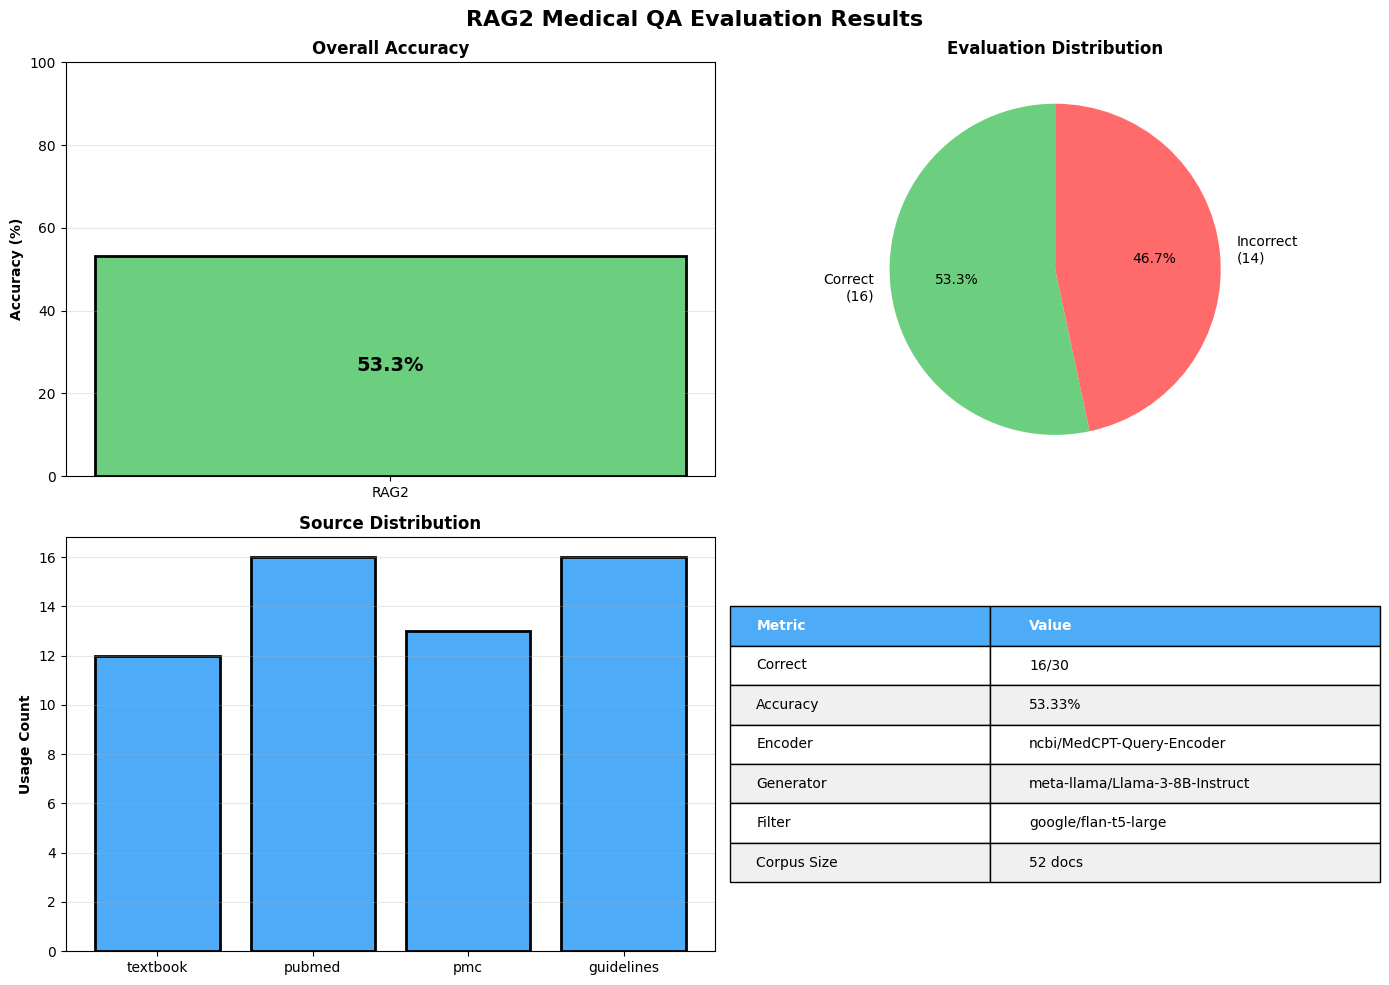

In [16]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RAG2 Medical QA Evaluation Results', fontsize=16, fontweight='bold')

# Plot 1: Accuracy Bar
acc = evaluation_results['accuracy']
ax1.bar(['RAG2'], [acc], color='#6bcf7f', edgecolor='black', linewidth=2)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Overall Accuracy', fontweight='bold')
ax1.text(0, acc/2, f'{acc:.1f}%', ha='center', va='center', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Correct vs Incorrect
sizes = [evaluation_results['correct'], evaluation_results['incorrect']]
labels = [f"Correct\n({evaluation_results['correct']})",
          f"Incorrect\n({evaluation_results['incorrect']})"]
colors = ['#6bcf7f', '#ff6b6b']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Evaluation Distribution', fontweight='bold')

# Plot 3: Source Distribution
source_counts = {}
for result in evaluation_results['detailed_results']:
    for source in result['sources_used']:
        source_counts[source] = source_counts.get(source, 0) + 1

if source_counts:
    ax3.bar(source_counts.keys(), source_counts.values(), color='#4dabf7', edgecolor='black', linewidth=2)
    ax3.set_ylabel('Usage Count', fontweight='bold')
    ax3.set_title('Source Distribution', fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)

# Plot 4: Summary Table
summary_data = [
    ['Metric', 'Value'],
    ['Correct', f"{evaluation_results['correct']}/{evaluation_results['total']}"],
    ['Accuracy', f"{acc:.2f}%"]
]

config = results_to_save['configuration']
summary_data.append(['Encoder', config['encoder']])
summary_data.append(['Generator', config['generator']])
summary_data.append(['Filter', config['filter']])
summary_data.append(['Corpus Size', f"{config['corpus_size']} docs"])

ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.4, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)


for i in range(2):
    table[(0, i)].set_facecolor('#4dabf7')
    table[(0, i)].set_text_props(weight='bold', color='white')


for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.tight_layout()
plt.savefig('rag2_evaluation_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to rag2_evaluation_results.png")
plt.show()